✅ Training Completed!

🏁 Best Path Learned by Agent:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


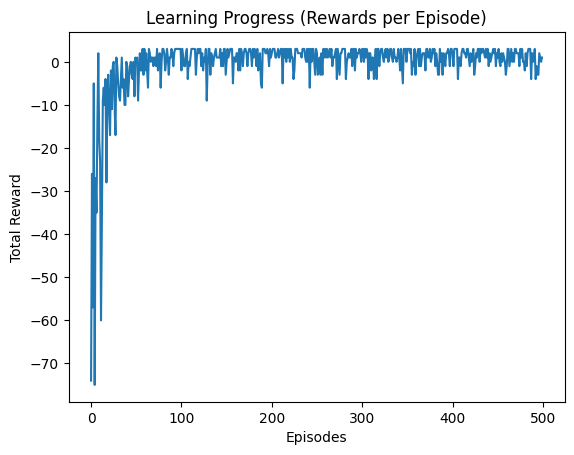

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ---------------------------
# 1️⃣ Environment Setup
# ---------------------------

# Grid size (5x5)
rows, cols = 5, 5

# Rewards grid
# -1 = normal cell, -10 = obstacle, +10 = goal
rewards = np.full((rows, cols), -1)

# Define goal and obstacles
goal = (4, 4)
obstacles = [(1, 1), (2, 1), (2, 3)]

for obs in obstacles:
    rewards[obs] = -10
rewards[goal] = 10

# ---------------------------
# 2️⃣ Q-Learning Setup
# ---------------------------

# Possible actions (Up, Down, Left, Right)
actions = ['up', 'down', 'left', 'right']

# Initialize Q-table (rows x cols x actions)
Q = np.zeros((rows, cols, len(actions)))

# Learning parameters
alpha = 0.1   # Learning rate
gamma = 0.9   # Discount factor
epsilon = 0.2 # Exploration rate (chance of random action)
episodes = 500 # How many times agent will play

# ---------------------------
# 3️⃣ Helper Functions
# ---------------------------

def is_valid(state):
    """Check if next move is inside grid and not an obstacle."""
    r, c = state
    if r < 0 or r >= rows or c < 0 or c >= cols:
        return False
    if state in obstacles:
        return False
    return True

def get_next_state(state, action):
    """Returns next state based on action."""
    r, c = state
    if action == 'up': r -= 1
    elif action == 'down': r += 1
    elif action == 'left': c -= 1
    elif action == 'right': c += 1

    new_state = (r, c)
    if not is_valid(new_state):
        return state  # invalid move → stay in same position
    return new_state

def choose_action(state):
    """Epsilon-greedy action selection."""
    if random.uniform(0, 1) < epsilon:
        # explore random action
        return random.choice(actions)
    else:
        r, c = state
        return actions[np.argmax(Q[r, c])]

# ---------------------------
# 4️⃣ Training the Agent
# ---------------------------

rewards_per_episode = []

for episode in range(episodes):
    state = (0, 0)  # start from top-left corner
    total_rewards = 0

    while state != goal:
        action = choose_action(state)
        next_state = get_next_state(state, action)
        r, c = state
        nr, nc = next_state

        reward = rewards[nr, nc]
        total_rewards += reward

        # Q-Learning formula
        Q[r, c, actions.index(action)] = Q[r, c, actions.index(action)] + alpha * (
            reward + gamma * np.max(Q[nr, nc]) - Q[r, c, actions.index(action)]
        )

        state = next_state

    rewards_per_episode.append(total_rewards)

print("✅ Training Completed!")

# ---------------------------
# 5️⃣ Finding the Best Path
# ---------------------------

state = (0, 0)
path = [state]

while state != goal:
    r, c = state
    action = actions[np.argmax(Q[r, c])]
    next_state = get_next_state(state, action)

    if next_state == state:
        # No movement possible → stop to avoid infinite loop
        break
    path.append(next_state)
    state = next_state

print("\n🏁 Best Path Learned by Agent:")
print(path)

# ---------------------------
# 6️⃣ Plotting the Learning Progress
# ---------------------------

plt.plot(rewards_per_episode)
plt.title("Learning Progress (Rewards per Episode)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.show()
